<a href="https://colab.research.google.com/github/FarahBelghith2/PFE/blob/main/Nettoyage_donn%C3%A9es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Partie 1 : Préparation et nettoyage des données

In [2]:

import pandas as pd
import numpy as np


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/PFE/base_plus_reelle_finale.csv', sep=';')
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce")

In [13]:
# =========================
# Recréer la colonne evenement_externe
# =========================

df["evenement_externe"] = "Aucun"

# Exemple d'événements
df.loc[
    (df["date"] >= pd.Timestamp("2012-05-16")) &
    (df["date"] <= pd.Timestamp("2012-05-27")),
    "evenement_externe"
] = "Festival de Cannes"

df.loc[
    (df["date"] >= pd.Timestamp("2012-05-27")) &
    (df["date"] <= pd.Timestamp("2012-06-10")),
    "evenement_externe"
] = "Roland-Garros"

df.loc[
    (df["date"] >= pd.Timestamp("2012-06-08")) &
    (df["date"] <= pd.Timestamp("2012-07-01")),
    "evenement_externe"
] = "Euro 2012"

df.loc[
    (df["date"] >= pd.Timestamp("2012-06-30")) &
    (df["date"] <= pd.Timestamp("2012-07-22")),
    "evenement_externe"
] = "Tour de France"

df.loc[df["date"] == pd.Timestamp("2012-05-19"), "evenement_externe"] = "Finale Champions League"
df.loc[df["date"] == pd.Timestamp("2012-06-21"), "evenement_externe"] = "Fête de la Musique"
df.loc[(df["date"] >= pd.Timestamp("2012-06-22")) & (df["date"] <= pd.Timestamp("2012-06-24")), "evenement_externe"] = "Solidays"
df.loc[(df["date"] >= pd.Timestamp("2012-06-29")) & (df["date"] <= pd.Timestamp("2012-07-01")), "evenement_externe"] = "Main Square Festival"
df.loc[(df["date"] >= pd.Timestamp("2012-07-19")) & (df["date"] <= pd.Timestamp("2012-07-22")), "evenement_externe"] = "Vieilles Charrues"
df.loc[(df["date"] >= pd.Timestamp("2012-08-24")) & (df["date"] <= pd.Timestamp("2012-08-26")), "evenement_externe"] = "Rock en Seine"
df.loc[df["date"] == pd.Timestamp("2012-10-07"), "evenement_externe"] = "Derby important"

# synchroniser
df["is_special_event"] = np.where(
    df["evenement_externe"].astype(str).str.strip().str.lower() != "aucun",
    1,
    0
)

print(df["evenement_externe"].value_counts(dropna=False))

evenement_externe
Aucun                      15651
Euro 2012                    408
Tour de France               408
Roland-Garros                288
Festival de Cannes           240
Vieilles Charrues             96
Rock en Seine                 72
Solidays                      72
Main Square Festival          72
Finale Champions League       24
Fête de la Musique            24
Derby important               24
Name: count, dtype: int64


In [14]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("[^0-9a-zA-Z_]", "", regex=True)
)

print(df.columns.tolist())

['date', 'heure', 'jour_semaine', 'saison', 'ferie', 'nom_ferie', 'jour_ouvrable', 'meteo', 'temperature_c', 'humidite_pct', 'vent_kmh', 'is_special_event', 'nom_evenement', 'capacite_max', 'reservations', 'taux_occupation', 'heure_num', 'reservations_avant', 'meteo_avant_patch', 'annee', 'mois', 'jour_mois', 'jour_semaine_num', 'heure_sin', 'heure_cos', 'evenement_externe']


# Partie 3 : Test des modèles de régression

In [28]:
X = df[[
    "saison",
    "heure",
    "jour_semaine",
    "ferie",
    "jour_ouvrable",
    "meteo",
    "temperature_c",
    "humidite_pct",
    "vent_kmh",
    "is_special_event"
]].copy()

y = df["reservations"].copy()

# Colonnes catégorielles
categorical_cols = ["saison", "heure", "jour_semaine", "meteo"]

# Encodage
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

3.1 Séparation des données en jeu d'entraînement et jeu de test

In [12]:
print("evenement_externe" in df.columns)
print(df.columns.tolist())

False
['date', 'heure', 'jour_semaine', 'saison', 'ferie', 'nom_ferie', 'jour_ouvrable', 'meteo', 'temperature_c', 'humidite_pct', 'vent_kmh', 'is_special_event', 'nom_evenement', 'capacite_max', 'reservations', 'taux_occupation', 'heure_num', 'reservations_avant', 'meteo_avant_patch', 'annee', 'mois', 'jour_mois', 'jour_semaine_num', 'heure_sin', 'heure_cos']


In [29]:

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()


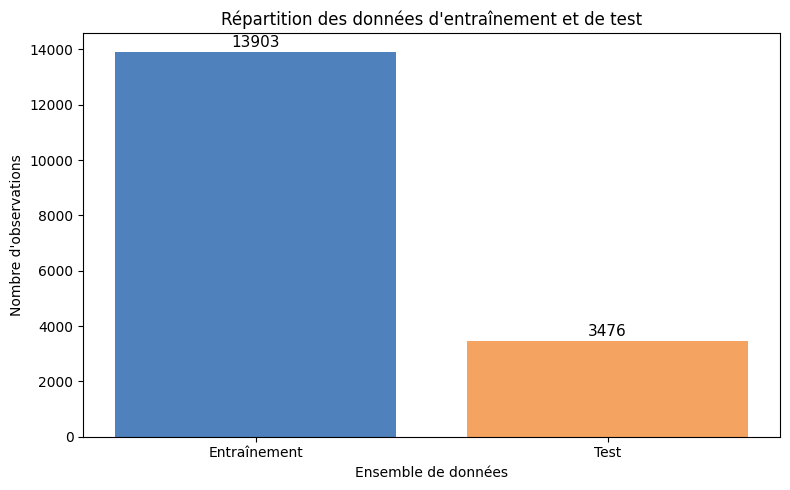

In [30]:
import matplotlib.pyplot as plt

# Nombre total d'observations
n = len(df)

# Même logique que le split réel
train = int(n * 0.8)
test = n - train

# Création du graphique
plt.figure(figsize=(8,5))
plt.bar(["Entraînement", "Test"], [train, test], color=["#4F81BD", "#F4A460"])

# Titre et axes
plt.title("Répartition des données d'entraînement et de test")
plt.xlabel("Ensemble de données")
plt.ylabel("Nombre d'observations")

# Afficher les valeurs sur les barres
for i, v in enumerate([train, test]):
    plt.text(i, v + n*0.01, str(v), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

## 3.2 Random Forest Regressor

> Ajouter une citation



In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_rf = np.maximum(0, y_pred_rf)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE  :", mae_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

Random Forest
MAE  : 2.0158879413483843
RMSE : 3.768584006436906
R²   : 0.9872305148374854


## 3.3 Gradient Boosting Regressor

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=200,random_state=42)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting")
print("MAE  :", mae_gbr)
print("RMSE :", rmse_gbr)
print("R²   :", r2_gbr)

Gradient Boosting
MAE  : 3.132625251935546
RMSE : 4.5631778568376555
R²   : 0.9812780199016954


## 3.4 XGBoost Regressor

In [33]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("MAE  :", mae_xgb)
print("RMSE :", rmse_xgb)
print("R²   :", r2_xgb)

XGBoost
MAE  : 2.0861897468566895
RMSE : 3.637892585884122
R²   : 0.9881008267402649


In [34]:
import pandas as pd

resultats_test = X_test.copy()

# Ajouter les vraies valeurs et les prédictions
resultats_test["reservations_reelles"] = y_test.values if hasattr(y_test, 'values') else y_test
resultats_test["reservations_predites"] = y_pred_xgb

In [ ]:
import pandas as pd
import numpy as np

# 1) Créer le tableau de base
resultats_test = X_test.copy()
resultats_test["reservations_reelles"] = y_test.values if hasattr(y_test, "values") else y_test
resultats_test["reservations_predites"] = y_pred_xgb

# 2) Définir le taux de promo
def decision_promo(row):
    if row["jour_semaine"] == 6:   # Dimanche
        return "0%"
    elif row["reservations_predites"] < 40:
        return "20%"
    elif row["reservations_predites"] < 80:
        return "10%"
    else:
        return "0%"

resultats_test["taux_promo"] = resultats_test.apply(decision_promo, axis=1)

# 3) Définir promo = 0/1
resultats_test["promo"] = resultats_test["taux_promo"].apply(lambda x: 0 if x == "0%" else 1)

# 4) Préparer l'affichage admin
affichage_admin = resultats_test.copy()

jours = {
    0: "Lundi",
    1: "Mardi",
    2: "Mercredi",
    3: "Jeudi",
    4: "Vendredi",
    5: "Samedi",
    6: "Dimanche"
}

affichage_admin["jour"] = affichage_admin["jour_semaine"].map(jours)
affichage_admin["promotion"] = affichage_admin["promo"].map({0: "Non", 1: "Oui"})
affichage_admin["reservations_predites"] = affichage_admin["reservations_predites"].round(0).astype(int)

def niveau_demande(val):
    if val < 40:
        return "Faible"
    elif val < 80:
        return "Moyenne"
    else:
        return "Élevée"

affichage_admin["niveau_demande"] = affichage_admin["reservations_predites"].apply(niveau_demande)
affichage_admin["heure"] = affichage_admin["heure"].apply(lambda x: f"{int(x):02d}h00")
# 5) Affichage final
if "heure" in affichage_admin.columns:
    tableau_admin = affichage_admin[[
        "jour", "heure", "reservations_predites", "niveau_demande", "promotion", "taux_promo"
    ]].copy()

    tableau_admin.columns = [
        "Jour", "Heure", "Réservations prévues", "Niveau de demande", "Promotion", "Taux recommandé"
    ]
else:
    tableau_admin = affichage_admin[[
        "jour", "reservations_predites", "niveau_demande", "promotion", "taux_promo"
    ]].copy()

    tableau_admin.columns = [
        "Jour", "Réservations prévues", "Niveau de demande", "Promotion", "Taux recommandé"
    ]

tableau_admin.head(20)

In [ ]:
tableau_admin[tableau_admin["Jour"] == "Dimanche"].head(10)

In [ ]:
tableau_admin["Taux recommandé"].value_counts()

### Partie 4 : Comparaison des performances

In [35]:
resultats = pd.DataFrame({
    "Modele": ["Random Forest", "Gradient Boosting", "XGBoost"],
    "MAE": [mae_rf, mae_gbr, mae_xgb],
    "RMSE": [rmse_rf, rmse_gbr, rmse_xgb],
    "R2": [r2_rf, r2_gbr, r2_xgb]
})

resultats

,Modele,MAE,RMSE,R2
0,Random Forest,2.015888,3.768584,0.987231
1,Gradient Boosting,3.132625,4.563178,0.981278
2,XGBoost,2.086190,3.637893,0.988101



# Partie 4 : courbes principales



In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Convertir y_test en tableau numpy si nécessaire
if hasattr(y_test, 'values'):
    y_test_plot = y_test.values
else:
    y_test_plot = np.array(y_test)

# Choisir le nombre de points à afficher
n = min(100, len(y_test_plot))

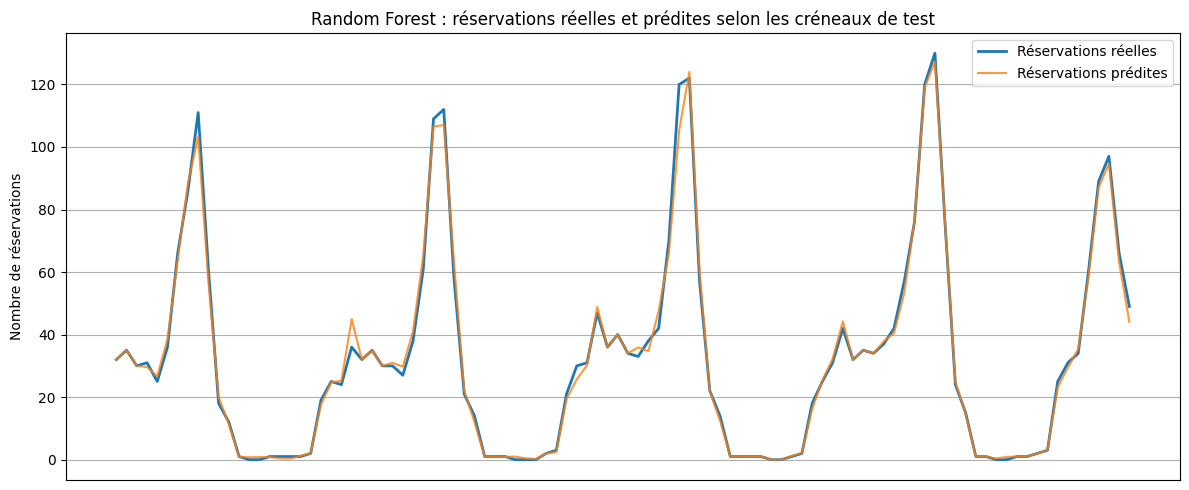

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_plot[:n], label='Réservations réelles', linewidth=2)
plt.plot(np.array(y_pred_rf)[:n], label='Réservations prédites', alpha=0.8)

plt.title('Random Forest : réservations réelles et prédites selon les créneaux de test')
plt.ylabel('Nombre de réservations')
plt.xticks([])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

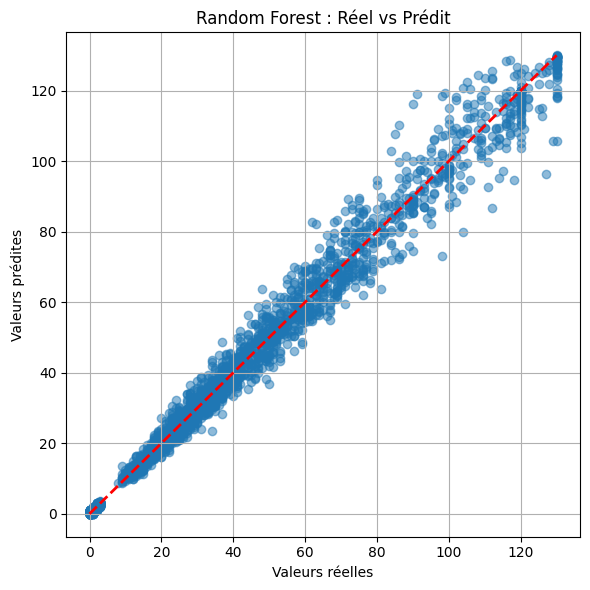

In [38]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_plot, y_pred_rf, alpha=0.5)
plt.plot([y_test_plot.min(), y_test_plot.max()],
         [y_test_plot.min(), y_test_plot.max()],
         'r--', linewidth=2)

plt.title('Random Forest : Réel vs Prédit')
plt.xlabel('Valeurs réelles')
plt.ylabel('Valeurs prédites')
plt.grid(True)
plt.tight_layout()
plt.show()

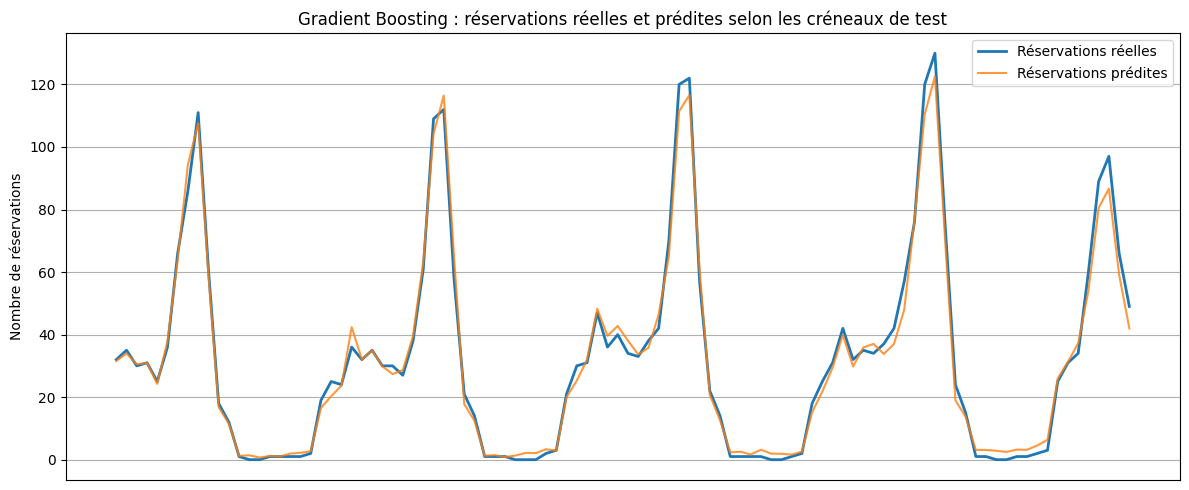

In [39]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_plot[:n], label='Réservations réelles', linewidth=2)
plt.plot(np.array(y_pred_gbr)[:n], label='Réservations prédites', alpha=0.8)

plt.title('Gradient Boosting : réservations réelles et prédites selon les créneaux de test')
plt.ylabel('Nombre de réservations')
plt.xticks([])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

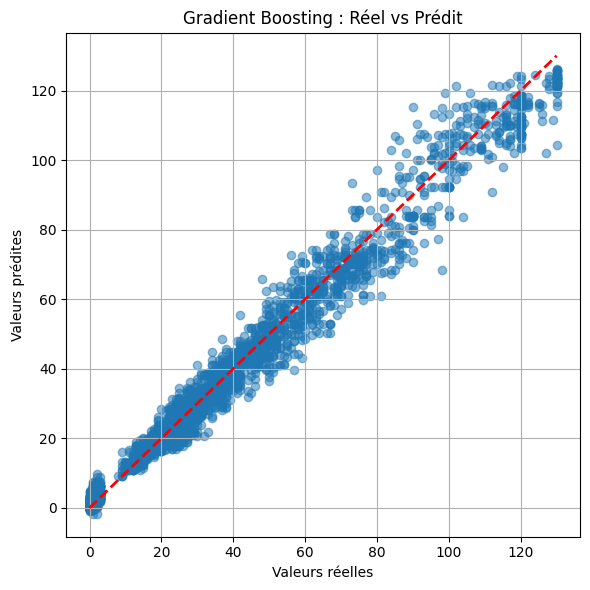

In [40]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_plot, y_pred_gbr, alpha=0.5)
plt.plot([y_test_plot.min(), y_test_plot.max()],
         [y_test_plot.min(), y_test_plot.max()],
         'r--', linewidth=2)

plt.title('Gradient Boosting : Réel vs Prédit')
plt.xlabel('Valeurs réelles')
plt.ylabel('Valeurs prédites')
plt.grid(True)
plt.tight_layout()
plt.show()

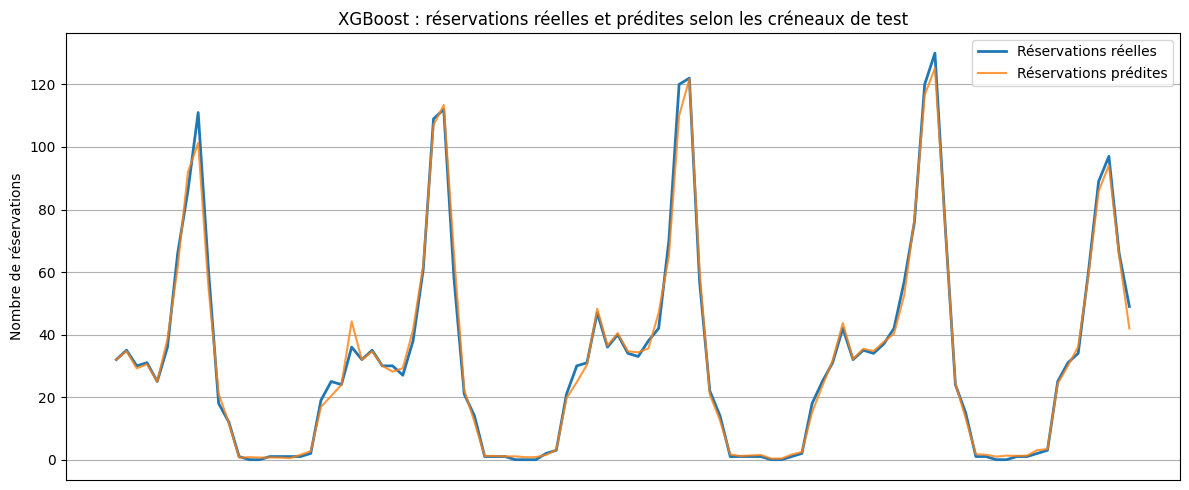

In [41]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_plot[:n], label='Réservations réelles', linewidth=2)
plt.plot(np.array(y_pred_xgb)[:n], label='Réservations prédites', alpha=0.8)

plt.title('XGBoost : réservations réelles et prédites selon les créneaux de test')
plt.ylabel('Nombre de réservations')
plt.xticks([])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

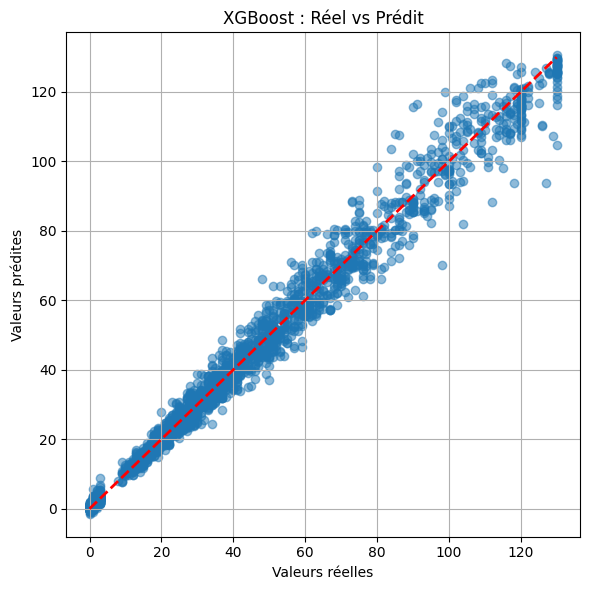

In [42]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_plot, y_pred_xgb, alpha=0.5)
plt.plot([y_test_plot.min(), y_test_plot.max()],
         [y_test_plot.min(), y_test_plot.max()],
         'r--', linewidth=2)

plt.title('XGBoost : Réel vs Prédit')
plt.xlabel('Valeurs réelles')
plt.ylabel('Valeurs prédites')
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Modèle simple
xgb = XGBRegressor(random_state=42)

# Entraînement
xgb.fit(X_train, y_train)

# Prédictions
y_pred_xgb = xgb.predict(X_test)

# Évaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor")
print("MAE  :", mae_xgb)
print("RMSE :", rmse_xgb)
print("R²   :", r2_xgb)

XGBoost Regressor
MAE  : 2.077235460281372
RMSE : 3.6896303133322257
R²   : 0.9877599477767944
